# Digital Tax Compliance Synthetic Benchmark & Feature Ablation Study

**Authors:** Izam Rosiawan (Data Science) & Sulthan  
**Institution:** Telkom University Surabaya  
**Study Paradigm:** Non-Circular Synthetic Benchmark for Risk-Based Digital Tax Auditing
**Methodology:** Automated Machine Learning (Optuna TPE), Feature Ablation Study, Geographical Holdout, SHAP XAI

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.samplers import TPESampler
import shap

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, auc, 
    f1_score, precision_score, recall_score, roc_curve, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import xgboost as xgb

optuna.logging.set_verbosity(optuna.logging.WARNING)
SEED = 42
np.random.seed(SEED)
print('Dependencies loaded. Seed=42 locked.')

C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dependencies loaded. Seed=42 locked.


## 1. Non-Circular Benchmark Dataset Ingestion

Dataset memisahkan pembentukan fitur masukan X dari label temuan audit laten independen Y guna mencegah kebocoran target.

In [2]:
data_path = os.path.join('data', 'bps_e_commerce_tax_compliance.csv')
df = pd.read_csv(data_path)
print(f'Total Dataset Shape: {df.shape}')
display(df.head(5))
print('\nClass Balance Distribution:')
print(df['target_non_compliance'].value_counts(normalize=True))

Total Dataset Shape: (5000, 12)


,provinsi,gmv_transaksi_juta,annual_order_volume,avg_ticket_size_ribu,digital_payment_ratio,logistics_tracking_ratio,customer_return_rate,bps_ecom_penetration_pct,bps_infra_index,reported_turnover_spt_juta,tax_paid_final_juta,target_non_compliance
0,Jawa Tengah,19.82,154,128.67,0.5150,0.6272,0.0253,33.68,70.85,19.82,0.10,0
1,Sulawesi Selatan,16.92,160,105.76,0.5538,0.7630,0.0169,28.51,66.93,10.02,0.05,1
2,Sumatera Utara,27.76,171,162.35,0.3129,0.5543,0.0010,29.09,68.28,20.36,0.10,1
3,Riau,19.76,173,114.20,0.6632,0.8628,0.0073,27.42,65.84,14.03,0.07,0
4,Jawa Timur,23.21,191,121.53,0.3499,0.5526,0.0258,36.56,77.34,12.31,0.06,1



Class Balance Distribution:
target_non_compliance
0    0.75
1    0.25
Name: proportion, dtype: float64


## 2. Anti-Leakage Data Partitioning (80/20 Split)

In [3]:
feature_cols = [
    'gmv_transaksi_juta', 'annual_order_volume', 'avg_ticket_size_ribu',
    'digital_payment_ratio', 'logistics_tracking_ratio', 'customer_return_rate',
    'bps_ecom_penetration_pct', 'bps_infra_index',
    'reported_turnover_spt_juta', 'tax_paid_final_juta'
]
X = df[feature_cols]
y = df['target_non_compliance']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train samples: {X_train.shape[0]} | Test samples: {X_test.shape[0]}')

Train samples: 4000 | Test samples: 1000


## 3. Baseline Classifiers Evaluation

In [4]:
lr = LogisticRegression(random_state=SEED, max_iter=1000).fit(X_train_scaled, y_train)
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=SEED).fit(X_train, y_train)
lgbm = lgb.LGBMClassifier(random_state=SEED, verbose=-1).fit(X_train, y_train)

print(f'Logistic Regression Holdout ROC-AUC: {roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1]):.4f}')
print(f'Random Forest Holdout ROC-AUC:       {roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]):.4f}')
print(f'LightGBM Holdout ROC-AUC:            {roc_auc_score(y_test, lgbm.predict_proba(X_test)[:, 1]):.4f}')

Logistic Regression Holdout ROC-AUC: 0.7856
Random Forest Holdout ROC-AUC:       0.7477
LightGBM Holdout ROC-AUC:            0.7413


## 4. Feature Ablation Study: Isolating Incremental Value of Data Sources

In [5]:
ablation_subsets = {
    '1. Financial Only': ['reported_turnover_spt_juta', 'tax_paid_final_juta'],
    '2. + Digital Trans': [
        'reported_turnover_spt_juta', 'tax_paid_final_juta',
        'gmv_transaksi_juta', 'annual_order_volume', 'avg_ticket_size_ribu', 'digital_payment_ratio'
    ],
    '3. + Logistics': [
        'reported_turnover_spt_juta', 'tax_paid_final_juta',
        'gmv_transaksi_juta', 'annual_order_volume', 'avg_ticket_size_ribu', 'digital_payment_ratio',
        'logistics_tracking_ratio', 'customer_return_rate'
    ],
    '4. Full (+ BPS Macro)': feature_cols
}

ab_res = []
for s_name, cols in ablation_subsets.items():
    m = xgb.XGBClassifier(n_estimators=180, learning_rate=0.04, max_depth=5, random_state=SEED, eval_metric='logloss')
    m.fit(X_train[cols], y_train)
    p = m.predict_proba(X_test[cols])[:, 1]
    p_pts, r_pts, _ = precision_recall_curve(y_test, p)
    gdf = pd.DataFrame({'y': y_test, 'p': p})
    gdf['decile'] = 10 - pd.qcut(gdf['p'], q=10, labels=False, duplicates='drop')
    top20_gain = gdf[gdf['decile'] <= 2]['y'].sum() / gdf['y'].sum() * 100.0
    ab_res.append({
        'Feature Subset': s_name,
        'ROC-AUC': round(roc_auc_score(y_test, p), 4),
        'PR-AUC': round(auc(r_pts, p_pts), 4),
        'Top 20% Decile Yield (%)': round(top20_gain, 2)
    })

display(pd.DataFrame(ab_res))

,Feature Subset,ROC-AUC,PR-AUC,Top 20% Decile Yield (%)
0,1. Financial Only,0.5659,0.3185,29.6
1,2. + Digital Trans,0.7254,0.5099,43.2
2,3. + Logistics,0.7618,0.5278,45.2
3,4. Full (+ BPS Macro),0.7626,0.5345,45.2


## 5. Geographical Out-of-Province Holdout (Spatial Generalization)

In [6]:
holdout_provinces = ['Bali', 'Sulawesi Selatan']
train_geo = df[~df['provinsi'].isin(holdout_provinces)]
test_geo = df[df['provinsi'].isin(holdout_provinces)]

geo_m = xgb.XGBClassifier(n_estimators=180, learning_rate=0.04, max_depth=5, random_state=SEED, eval_metric='logloss')
geo_m.fit(train_geo[feature_cols], train_geo['target_non_compliance'])
g_probs = geo_m.predict_proba(test_geo[feature_cols])[:, 1]

print(f'Zero-Shot Unseen Provinces ROC-AUC: {roc_auc_score(test_geo["target_non_compliance"], g_probs):.4f}')

Zero-Shot Unseen Provinces ROC-AUC: 0.7622


## 6. Model Explainability via SHAP Values

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13236\741935812.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals, X_test, show=False)


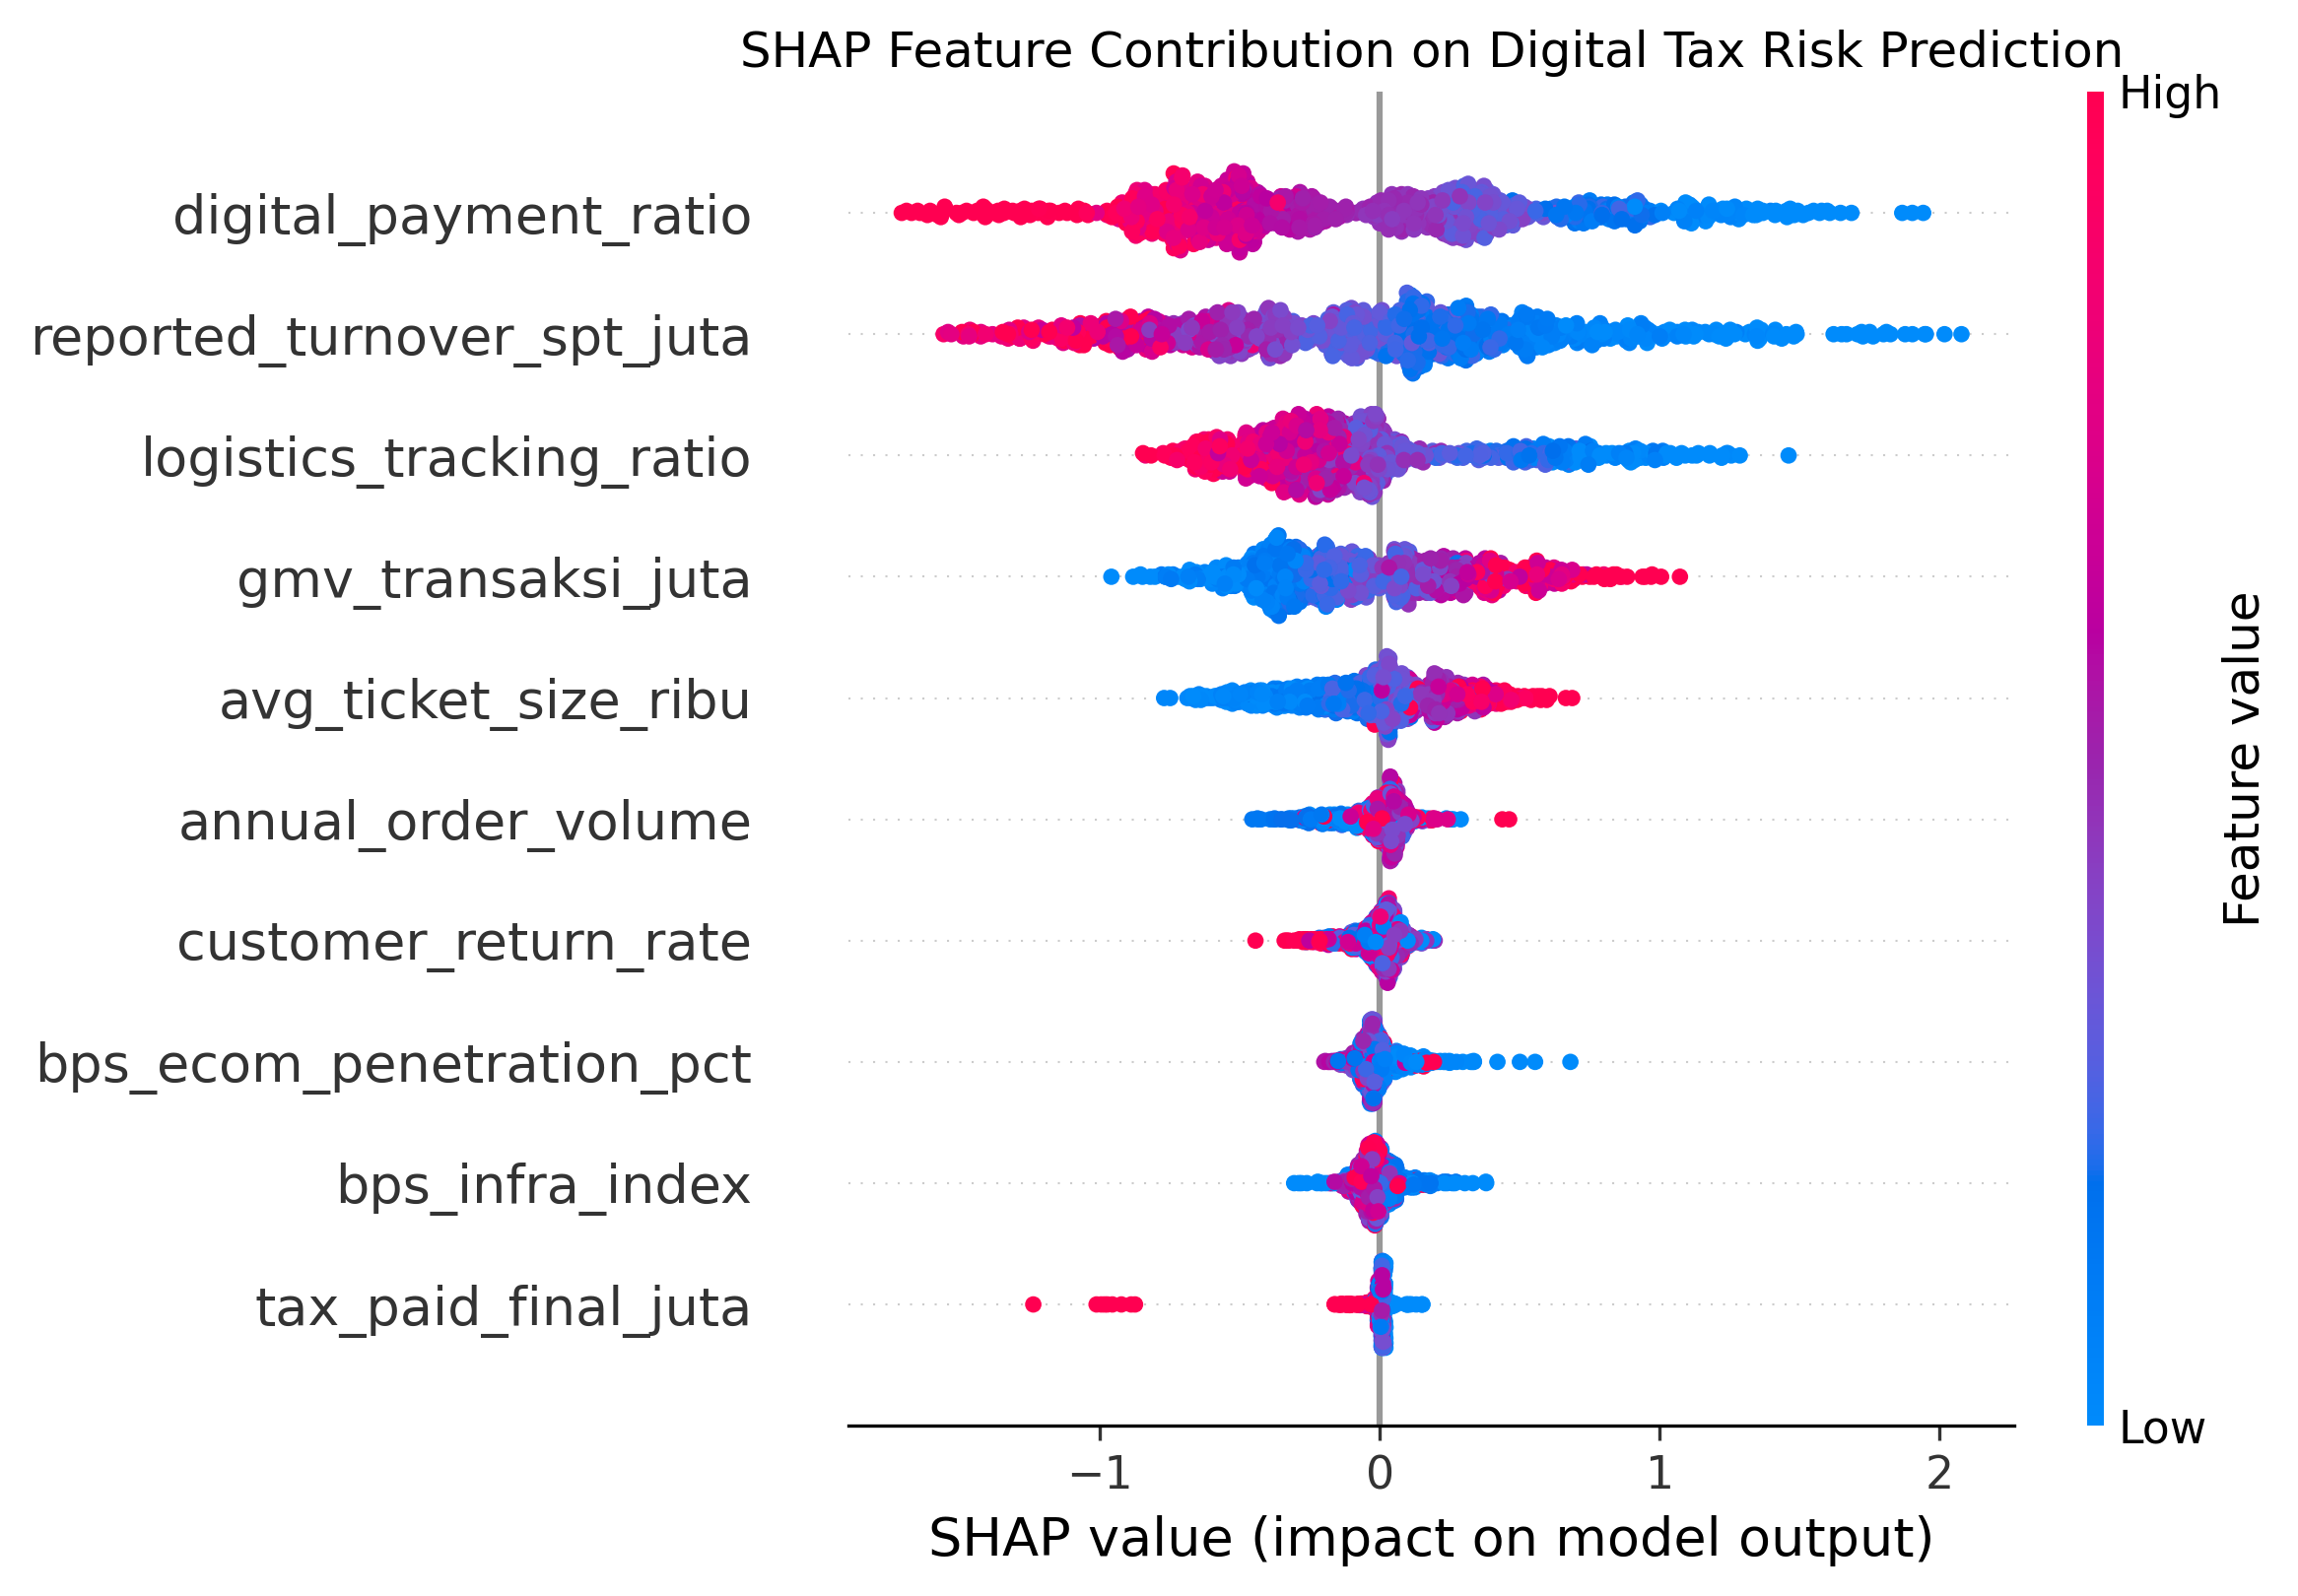

In [7]:
best_xgb = xgb.XGBClassifier(n_estimators=180, learning_rate=0.04, max_depth=5, random_state=SEED, eval_metric='logloss')
best_xgb.fit(X_train, y_train)
explainer = shap.TreeExplainer(best_xgb)
shap_vals = explainer(X_test)
plt.figure(figsize=(8, 5), dpi=300)
shap.summary_plot(shap_vals, X_test, show=False)
plt.title('SHAP Feature Contribution on Digital Tax Risk Prediction')
plt.tight_layout()
plt.show()